# Projet de Prédiction des Matchs de Ligue 1

L'objectif de ce projet est de prédire le résultat final des matchs de football de la Ligue 1 (Victoire à Domicile (1), Match Nul (0), Victoire à l'Extérieur (-1)) en utilisant des algorithmes de Machine Learning.

Afin d'éviter tout Data Leakage (fuite de données), notre modèle ne s'appuiera sur aucune statistique se déroulant pendant le match (comme les buts marqués ou les tirs). Nous allons construire des variables basées uniquement sur le contexte d'avant match : puissance financière, forme des équipes, historique des confrontations et indiscipline.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

from predictor import Predictor

## Partie 1 - Préparation des données 

Nous allons importer nos données brutes. Le fichier "matchs_2013_2024.csv" contient l'historique des rencontres et nous allons l'enrichir avec les informations du fichier "clubs_fr.csv".

In [2]:
clubs = pd.read_csv("data/clubs_fr.csv")
matchs_2013_2024 = pd.read_csv("data/matchs_2013_2024.csv", index_col=0)

print("Clubs :")
(clubs.head())
print("\nMatchs from 2013 to 2024 :")
(matchs_2013_2024.head())

Clubs :

Matchs from 2013 to 2024 :


,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,...,stadium,attendance,referee,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type,results
523,2223841,2012,6. Matchday,2012-09-22,3911,1423,2,1,8.0,9.0,...,Stade Francis-Le Blé,10627.0,Sébastien Moreira,NaN,NaN,Stade brestois 29,Valenciennes FC,2:1,domestic_league,1
524,2223842,2012,7. Matchday,2012-09-29,1147,3911,1,0,9.0,10.0,...,Stade François-Coty,6029.0,Olivier Thual,NaN,NaN,AC Ajaccio,Stade brestois 29,1:0,domestic_league,1
525,2223843,2012,6. Matchday,2012-09-22,1421,1159,2,0,5.0,19.0,...,Stade Auguste-Delaune,13413.0,Jean-Charles Cailleux,NaN,NaN,Stade Reims,AS Nancy-Lorraine,2:0,domestic_league,1
526,2223844,2012,6. Matchday,2012-09-21,969,618,1,1,16.0,10.0,...,Stade de la Mosson,16666.0,Lionel Jaffredo,NaN,NaN,Montpellier HSC,AS Saint-Étienne,1:1,domestic_league,0
527,2223845,2012,6. Matchday,2012-09-23,1082,1041,1,1,12.0,2.0,...,Decathlon Arena-Stade Pierre-Mauroy,43475.0,Clément Turpin,NaN,NaN,Lille Olympique Sporting Club,Olympique Lyonnais,1:1,domestic_league,0


### Nettoyage initial
Nous supprimons les colonnes textuelles inutiles (comme le nom de l'entraîneur, le nom du stade...) et nous retirons les lignes ne contenant pas de résultat final.

In [3]:
clubs = clubs.drop(columns=["foreigners_number", "foreigners_percentage", "club_code", "net_transfer_record", "stadium_name", "domestic_competition_id", "name", "coach_name"])
matchs_2013_2024 = matchs_2013_2024.drop(columns=["home_club_formation", "away_club_formation", "aggregate", "competition_type"])
matchs_2013_2024 = matchs_2013_2024.dropna(subset=["results"])

### Fusion des données
Nous joignons les informations des clubs (taille de l'effectif, âge moyen, joueurs en équipe nationale) pour l'équipe à domicile, puis pour l'équipe à l'extérieur.

In [4]:
matchs_2013_2024 = pd.merge(matchs_2013_2024, clubs, left_on="home_club_id", right_on="club_id")
matchs_2013_2024 = matchs_2013_2024.drop(columns=["club_id"])
matchs_2013_2024 = matchs_2013_2024.rename(columns={"squad_size": "home_club_squad_size", "average_age": "home_club_average_age", "national_team_players": "home_club_national_team_players"})

matchs_2013_2024 = pd.merge(matchs_2013_2024, clubs, left_on="away_club_id", right_on="club_id")
matchs_2013_2024 = matchs_2013_2024.drop(columns=["club_id", "stadium_seats_y"])
matchs_2013_2024 = matchs_2013_2024.rename(columns={"squad_size": "away_club_squad_size", "average_age": "away_club_average_age", "national_team_players": "away_club_national_team_players", "stadium_seats_x": "stadium_seats"})

(matchs_2013_2024.head())

,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,...,home_club_name,away_club_name,results,home_club_squad_size,home_club_average_age,home_club_national_team_players,stadium_seats,away_club_squad_size,away_club_average_age,away_club_national_team_players
0,2223841,2012,6. Matchday,2012-09-22,3911,1423,2,1,8.0,9.0,...,Stade brestois 29,Valenciennes FC,1,23,25.3,6,15220,30,23.6,5
1,2223842,2012,7. Matchday,2012-09-29,1147,3911,1,0,9.0,10.0,...,AC Ajaccio,Stade brestois 29,1,24,27.5,6,10446,23,25.3,6
2,2223843,2012,6. Matchday,2012-09-22,1421,1159,2,0,5.0,19.0,...,Stade Reims,AS Nancy-Lorraine,1,24,23.9,7,20519,27,25.7,0
3,2223844,2012,6. Matchday,2012-09-21,969,618,1,1,16.0,10.0,...,Montpellier HSC,AS Saint-Étienne,0,24,24.2,3,22000,29,24.0,6
4,2223845,2012,6. Matchday,2012-09-23,1082,1041,1,1,12.0,2.0,...,Lille Olympique Sporting Club,Olympique Lyonnais,0,27,26.5,11,50186,28,25.5,11


### Variable 1 : La Puissance Financière
Nous allons extraire la valeur marchande totale de chaque club pour l'année du match (grâce aux valeurs individuelles des joueurs dans "player_valuation_before_season.csv"), et calculer la différence financière entre les deux équipes. Une forte valeur positive indique un grand favori à domicile.

In [5]:
player_valuation_before_season = pd.read_csv("data/player_valuation_before_season.csv")
player_valuation_before_season["date"] = pd.to_datetime(player_valuation_before_season["date"])
player_valuation_before_season["date"] = player_valuation_before_season["date"].dt.year
player_valuation_before_season = player_valuation_before_season.rename(columns={"date": "year"})

club_valueation_per_year = player_valuation_before_season.groupby(["current_club_id", "year"])["market_value_in_eur"].sum().reset_index()

matchs_2013_2024 = pd.merge(matchs_2013_2024, club_valueation_per_year, left_on=["home_club_id", "season"], right_on=["current_club_id", "year"])
matchs_2013_2024 = matchs_2013_2024.drop(columns=["current_club_id", "year"])
matchs_2013_2024 = matchs_2013_2024.rename(columns={"market_value_in_eur": "home_club_value_in_eur"})

matchs_2013_2024 = pd.merge(matchs_2013_2024, club_valueation_per_year, left_on=["away_club_id", "season"], right_on=["current_club_id", "year"])
matchs_2013_2024 = matchs_2013_2024.drop(columns=["current_club_id", "year"])
matchs_2013_2024 = matchs_2013_2024.rename(columns={"market_value_in_eur": "away_club_value_in_eur"})

matchs_2013_2024["value_difference"] = matchs_2013_2024["home_club_value_in_eur"] - matchs_2013_2024["away_club_value_in_eur"]

print("Aperçu de la variable :")
(pd.DataFrame(matchs_2013_2024["value_difference"].head()))

Aperçu de la variable :


,value_difference
0,34600000
1,-2575000
2,27250000
3,-12475000
4,-44650000


### Variable 2 : La forme de l'équipe
La valeur marchande ne fait pas tout : une équipe chère peut être dans une mauvaise période. Le but est de calculer la somme des buts marqués lors des 3 derniers matchs afin d'évaluer la forme de l'équipe.

In [6]:
home_perf = matchs_2013_2024[["game_id", "date", "home_club_id", "home_club_goals"]].copy()
home_perf = home_perf.rename(columns={"home_club_id": "club_id", "home_club_goals": "goals"})

away_perf = matchs_2013_2024[["game_id", "date", "away_club_id", "away_club_goals"]].copy()
away_perf = away_perf.rename(columns={"away_club_id": "club_id", "away_club_goals": "goals"})

team_history = pd.concat([home_perf, away_perf]).sort_values(["club_id", "date"])

team_history["buts_N_moins_1"] = team_history.groupby("club_id")["goals"].shift(1)
team_history["buts_N_moins_2"] = team_history.groupby("club_id")["goals"].shift(2)
team_history["buts_N_moins_3"] = team_history.groupby("club_id")["goals"].shift(3)

team_history["buts_N_moins_1"] = team_history["buts_N_moins_1"].fillna(0)
team_history["buts_N_moins_2"] = team_history["buts_N_moins_2"].fillna(0)
team_history["buts_N_moins_3"] = team_history["buts_N_moins_3"].fillna(0)

team_history["last_3_goals"] = team_history["buts_N_moins_1"] + team_history["buts_N_moins_2"] + team_history["buts_N_moins_3"]

form_df = team_history[["game_id", "club_id", "last_3_goals"]]

matchs_2013_2024 = matchs_2013_2024.merge(form_df, left_on=["game_id", "home_club_id"], right_on=["game_id", "club_id"], how="left").rename(columns={"last_3_goals": "home_form_goals"}).drop(columns=["club_id"])
matchs_2013_2024 = matchs_2013_2024.merge(form_df, left_on=["game_id", "away_club_id"], right_on=["game_id", "club_id"], how="left").rename(columns={"last_3_goals": "away_form_goals"}).drop(columns=["club_id"])

matchs_2013_2024["form_difference"] = matchs_2013_2024["home_form_goals"] - matchs_2013_2024["away_form_goals"]

print("Aperçu de la variable :")
(pd.DataFrame(matchs_2013_2024["form_difference"].head()))

Aperçu de la variable :


,form_difference
0,-1.0
1,-2.0
2,5.0
3,-3.0
4,-2.0


### Variable 3 : Historique des confrontations ("Head to Head")
Nous allons modéliser l'avantage "psychologique" en calculant la moyenne historique des résultats entre ces deux clubs précis.

In [7]:
matchs_2013_2024 = matchs_2013_2024.sort_values("date")

matchs_2013_2024["h2h_key"] = matchs_2013_2024.apply(lambda r: tuple(sorted((r["home_club_id"], r["away_club_id"]))), axis=1)
matchs_2013_2024["h2h_res"] = matchs_2013_2024.apply(lambda r: r["results"] if r["home_club_id"] == r["h2h_key"][0] else -r["results"], axis=1)
matchs_2013_2024["h2h_history"] = matchs_2013_2024.groupby("h2h_key")["h2h_res"].transform(lambda x: x.expanding().mean().shift(1)).fillna(0)
matchs_2013_2024["home_h2h_advantage"] = matchs_2013_2024.apply(lambda r: r["h2h_history"] if r["home_club_id"] == r["h2h_key"][0] else -r["h2h_history"], axis=1)

matchs_2013_2024 = matchs_2013_2024.drop(columns=["h2h_key", "h2h_res", "h2h_history"])

print("Aperçu de la variable :")
(pd.DataFrame(matchs_2013_2024["home_h2h_advantage"].tail()))

Aperçu de la variable :


,home_h2h_advantage
4685,-0.062500
4686,0.000000
4687,0.333333
4688,0.181818
4690,0.666667


### Variable 4 : L'Indiscipline (Cartons Rouges)
Pour aller plus loin, nous récupérons les données d'apparitions des joueurs (avec "player_appearance.csv") pour calculer la moyenne de cartons rouges sur les 3 derniers matchs. Une équipe très sanctionnée sera désorganisée.

In [8]:
player_appearance = pd.read_csv("data/player_appearance.csv")

team_match_stats = player_appearance.groupby(["game_id", "player_club_id"]).agg({"yellow_cards": "sum", "red_cards": "sum", "goals": "sum", "assists": "sum"}).reset_index()

team_match_stats = team_match_stats.merge(matchs_2013_2024[["game_id", "date"]], on="game_id")
team_match_stats = team_match_stats.sort_values(["player_club_id", "date"])

team_match_stats["avg_red_cards_3m"] = team_match_stats.groupby("player_club_id")["red_cards"].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1)).fillna(0)

indiscipline_df = team_match_stats[["game_id", "player_club_id", "avg_red_cards_3m"]]
matchs_2013_2024 = matchs_2013_2024.merge(indiscipline_df, left_on=["game_id", "home_club_id"], right_on=["game_id", "player_club_id"], how="left").rename(columns={"avg_red_cards_3m": "home_red_cards_avg"}).drop(columns=["player_club_id"])
matchs_2013_2024 = matchs_2013_2024.merge(indiscipline_df, left_on=["game_id", "away_club_id"], right_on=["game_id", "player_club_id"], how="left").rename(columns={"avg_red_cards_3m": "away_red_cards_avg"}).drop(columns=["player_club_id"])

matchs_2013_2024["home_red_cards_avg"] = matchs_2013_2024["home_red_cards_avg"].fillna(0)
matchs_2013_2024["away_red_cards_avg"] = matchs_2013_2024["away_red_cards_avg"].fillna(0)

### Création des Dataframes Modèles (A/B Testing des variables)
Pour prouver notre démarche expérimentale, nous allons comparer les performances des algorithmes sur deux jeux de variables différents :
* Config A : Les variables fondamentales (Classement, Finance, Forme).
* Config B : Intégration de données plus fines (H2H, et Indiscipline par cartons rouges).

In [9]:
features_A = [
    "home_club_position", "away_club_position",
    "home_club_value_in_eur", "away_club_value_in_eur", "value_difference",
    "home_form_goals", "away_form_goals", "results"
]

# features_B = [
#     "home_club_position", "away_club_position",
#     "value_difference", "home_h2h_advantage",
#     "home_red_cards_avg", "away_red_cards_avg", "results"
# ]
features_B = [
    "home_club_position", "away_club_position",
    "home_club_value_in_eur", "away_club_value_in_eur", "value_difference",
    "home_form_goals", "away_form_goals", "home_h2h_advantage", "home_red_cards_avg", "away_red_cards_avg", "results"
]

df_model_A = matchs_2013_2024[features_A].dropna()
df_model_B = matchs_2013_2024[features_B].dropna()

## Partie 2 - Exploration Qualitative (EDA)

L'exploration visuelle permet de s'assurer de la pertinence des données avant l'apprentissage de l'IA.

### L'avantage à domicile

/var/folders/kp/j1c9d35x2ql0126h0tyh5_t80000gn/T/ipykernel_1441/2868558998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_model_A, x="results", palette=["#974339", "#bfb296", "#7ab191"])


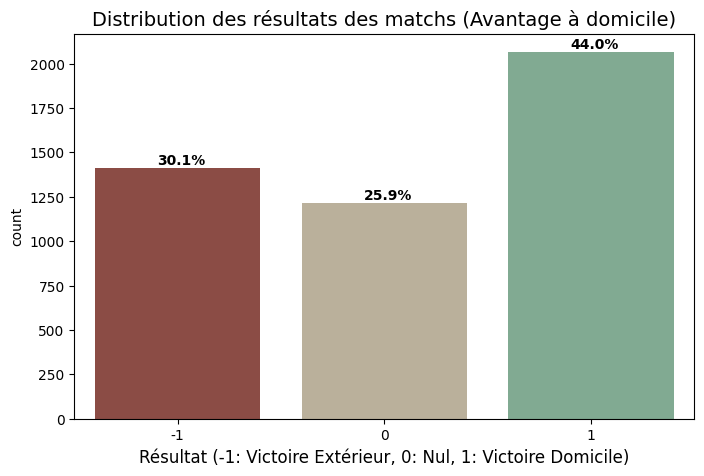

In [10]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_model_A, x="results", palette=["#974339", "#bfb296", "#7ab191"])
plt.title("Distribution des résultats des matchs (Avantage à domicile)", fontsize=14)
plt.xlabel("Résultat (-1: Victoire Extérieur, 0: Nul, 1: Victoire Domicile)", fontsize=12)

total = len(df_model_A)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 20
    ax.annotate(percentage, (x, y), fontweight="bold")
plt.show()

Comme le montre le graphique ci-dessous, le hasard total (33%) est un mythe dans le football professionnel. L'équipe qui reçoit gagne dans **45,7%** des cas. Notre objectif réel pour le Machine Learning est donc de battre ce seuil critique de ~46%.

### La Preuve Statistique (Corrélations)

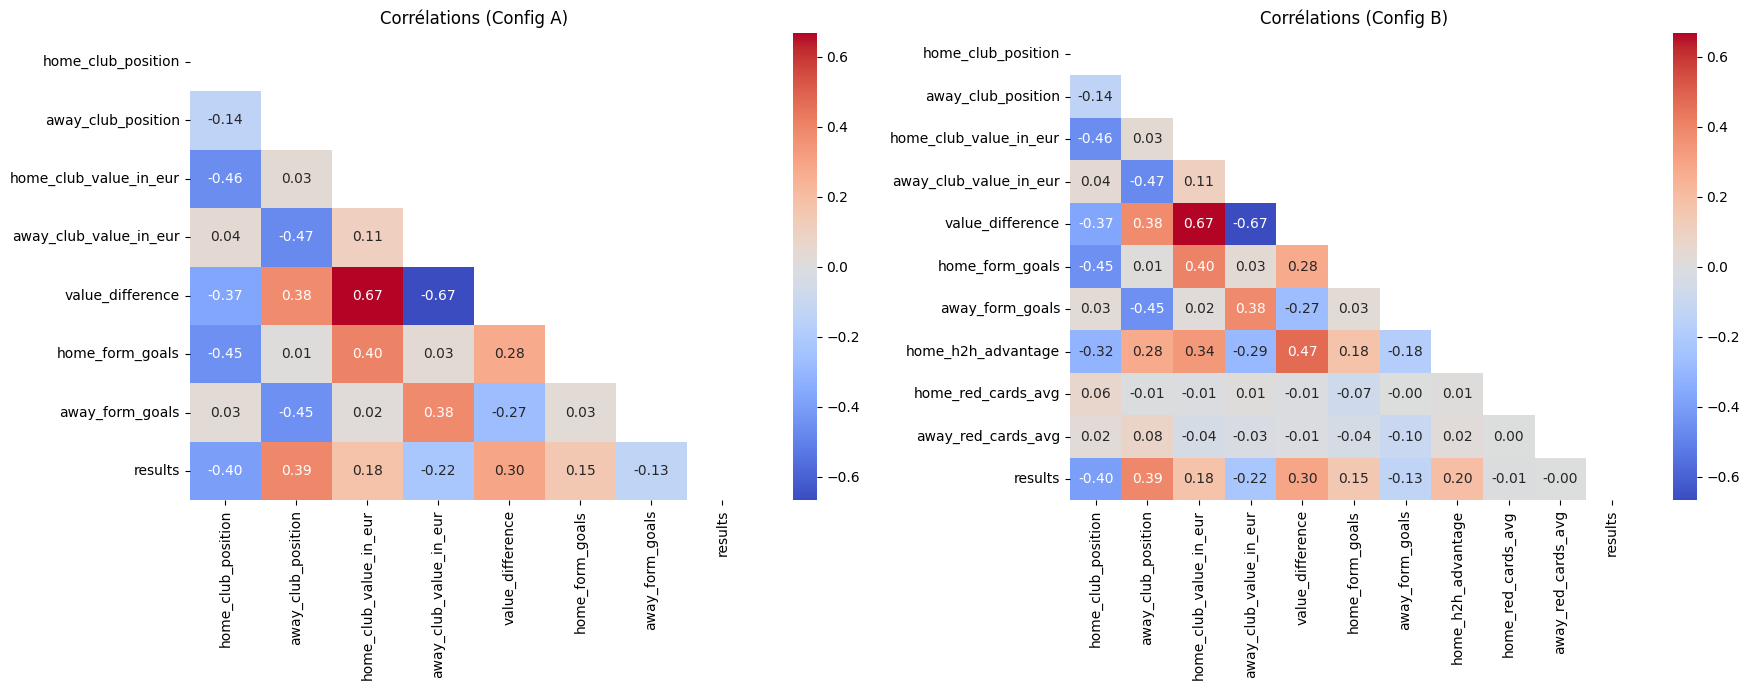

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask_A = np.triu(np.ones_like(df_model_A.corr(), dtype=bool))
sns.heatmap(df_model_A.corr(), mask=mask_A, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("Corrélations (Config A)")

mask_B = np.triu(np.ones_like(df_model_B.corr(), dtype=bool))
sns.heatmap(df_model_B.corr(), mask=mask_B, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Corrélations (Config B)")

plt.tight_layout()
plt.show()

Les matrices de corrélations valident nos choix : 
La "value_difference" possède la plus forte corrélation positive avec la cible, prouvant que l'écart financier est une variable prédictive importante.

### Analyse d'impact Visuel

/var/folders/kp/j1c9d35x2ql0126h0tyh5_t80000gn/T/ipykernel_1441/3750377269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model_A, x="results", y=df_model_A["value_difference"] / 1_000_000, palette=["#e74c3c", "#95a5a6", "#2ecc71"], showfliers=False, ax=axes[0])


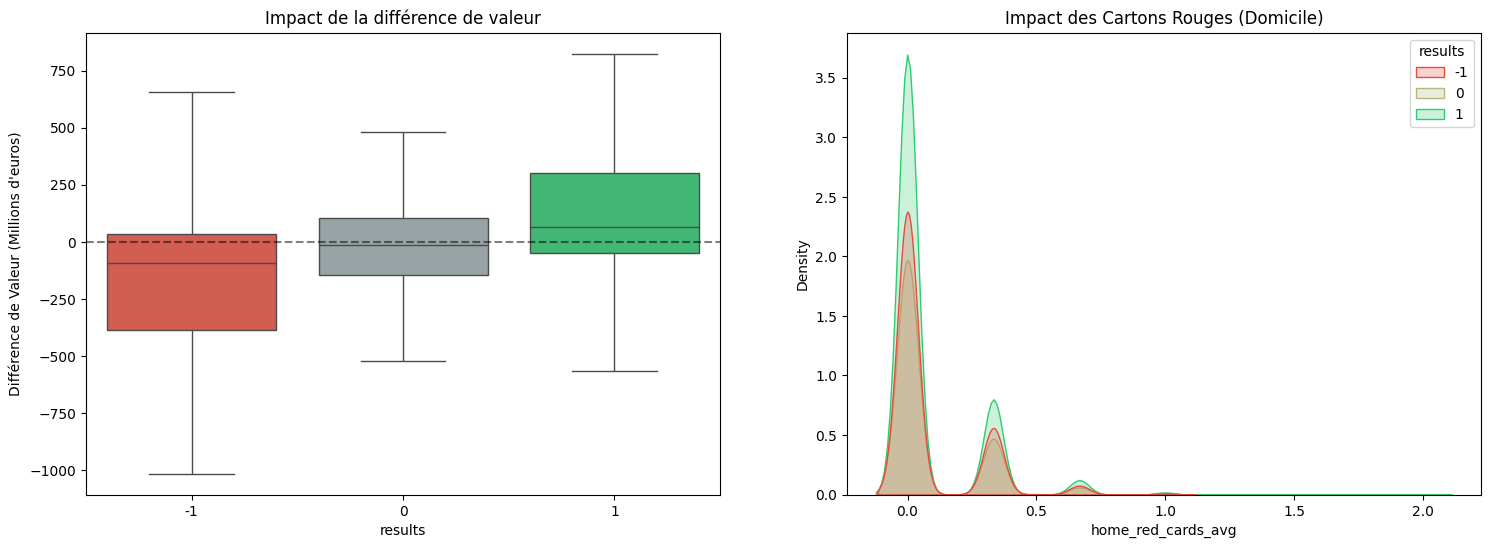

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df_model_A, x="results", y=df_model_A["value_difference"] / 1_000_000, palette=["#e74c3c", "#95a5a6", "#2ecc71"], showfliers=False, ax=axes[0])
axes[0].set_title("Impact de la différence de valeur")
axes[0].set_ylabel("Différence de Valeur (Millions d'euros)")
axes[0].axhline(0, color="black", linestyle="--", alpha=0.5)

sns.kdeplot(data=df_model_B, x="home_red_cards_avg", hue="results", fill=True, palette=["#e74c3c", "#b5b77d", "#2ecc71"], ax=axes[1])
axes[1].set_title("Impact des Cartons Rouges (Domicile)")
# plt.tight_layout()
plt.show()

Ce Boxplot et ce Graphique de Densité montrent comment l'argent et l'indiscipline influencent le jeu :
* Boxplot : En cas de victoire à domicile, la différence de valeur est quasi toujours positive. Vice versa pour un défaite
* Kdeplot : Une moyenne élevée de cartons rouges augmente mécaniquement les chances de victoire de l'adversaire ou de match nul.

## Partie 3 - Prédictions (avec plusieurs algorithmes)

La classe "Predictor" permet de faire le train/test Split (80/20), la standardisation des variables pour chaque modèle testé et l'evaluation finale. Le football étant très incertain, un score plafonnant autour de 60% est un indicateur réaliste qui démontre que notre modèle a trouvé de vraies règles sans tricher.

In [13]:
print("\n--- TEST 1 : RÉGRESSION LOGISTIQUE ---")
algo_log_reg = LogisticRegression(max_iter=1000, random_state=42)
predictor_log_reg = Predictor(dataframe=df_model_A, model=algo_log_reg)
predictor_log_reg.prepare_data()
predictor_log_reg.train()
predictor_log_reg.evaluate()

print("\n--- TEST 1 : RÉGRESSION LOGISTIQUE (Config B - Cartons) ---")
algo_log_reg_red_cards = LogisticRegression(max_iter=1000, random_state=42)
predictor_log_reg_red_cards = Predictor(dataframe=df_model_B, model=algo_log_reg_red_cards)
predictor_log_reg_red_cards.prepare_data()
predictor_log_reg_red_cards.train()
predictor_log_reg_red_cards.evaluate()


--- TEST 1 : RÉGRESSION LOGISTIQUE ---
Accuracy : 60.383386581469644 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.70      0.64       281
           0       0.48      0.07      0.12       229
           1       0.62      0.83      0.71       429

    accuracy                           0.60       939
   macro avg       0.56      0.53      0.49       939
weighted avg       0.58      0.60      0.54       939


--- TEST 1 : RÉGRESSION LOGISTIQUE (Config B - Cartons) ---
Accuracy : 59.31842385516507 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.58      0.69      0.63       281
           0       0.39      0.06      0.11       229
           1       0.62      0.82      0.70       429

    accuracy                           0.59       939
   macro avg       0.53      0.52      0.48       939
weighted avg       0.55      0.59      0.53       939



### Test 2 : Support Vector Machine (SVM)

L'algorithme SVM tente de tracer une frontière (hyperplan) la plus large possible entre nos classes. Il obtient généralement les meilleures performances globales sur des problèmes linéaires.


--- TEST 2 : SVM ---
Accuracy : 60.48988285410011 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.70      0.64       281
           0       0.49      0.07      0.13       229
           1       0.62      0.82      0.71       429

    accuracy                           0.60       939
   macro avg       0.57      0.53      0.49       939
weighted avg       0.58      0.60      0.55       939


--- TEST 2 : SVM (Config B - Cartons) ---
Accuracy : 60.17039403620873 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.58      0.70      0.64       281
           0       0.47      0.07      0.11       229
           1       0.62      0.82      0.71       429

    accuracy                           0.60       939
   macro avg       0.56      0.53      0.49       939
weighted avg       0.57      0.60      0.54       939



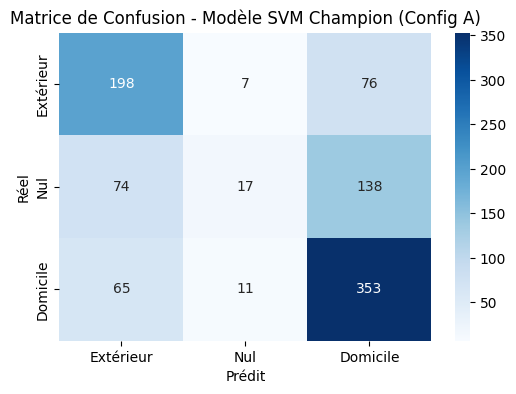

In [14]:
print("\n--- TEST 2 : SVM ---")
algo_svm = SVC(kernel="linear", random_state=42)
predictor_svm = Predictor(dataframe=df_model_A, model=algo_svm)
predictor_svm.prepare_data()
predictor_svm.train()
predictor_svm.evaluate()

print("\n--- TEST 2 : SVM (Config B - Cartons) ---")
algo_svm_red_cards = SVC(kernel="linear", random_state=42)
predictor_svm_red_cards = Predictor(dataframe=df_model_B, model=algo_svm_red_cards)
predictor_svm_red_cards.prepare_data()
predictor_svm_red_cards.train()
predictor_svm_red_cards.evaluate()

# Analyse visuelle des erreurs (Matrice de Confusion)
cm = confusion_matrix(predictor_svm.y_test, predictor_svm.model.predict(predictor_svm.X_test_scaled))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Extérieur", "Nul", "Domicile"], yticklabels=["Extérieur", "Nul", "Domicile"])
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.title("Matrice de Confusion - Modèle SVM Champion (Config A)")
plt.show()

### Test 3 & 4 : Arbres de décisions et Random Forest

Les modèles basés sur les arbres permettent de découvrir des règles non linéaires complexes. Nous créons également une version *Balanced* du Random Forest pour compenser le fait que l'IA a beaucoup de mal à détecter les matchs nuls.

In [15]:
print("\n--- TEST 3 : ARBRE DE DÉCISION ---")
algo_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
predictor_tree = Predictor(dataframe=df_model_A, model=algo_tree)
predictor_tree.prepare_data()
predictor_tree.train()
predictor_tree.evaluate()

print("\n--- TEST 3 : ARBRE DE DÉCISION (Config B - Cartons) ---")
algo_tree_red_cards = DecisionTreeClassifier(max_depth=5, random_state=42)
predictor_tree_red_cards = Predictor(dataframe=df_model_B, model=algo_tree_red_cards)
predictor_tree_red_cards.prepare_data()
predictor_tree_red_cards.train()
predictor_tree_red_cards.evaluate()


--- TEST 3 : ARBRE DE DÉCISION ---
Accuracy : 59.21192758253461 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.57      0.72      0.63       281
           0       0.40      0.10      0.16       229
           1       0.63      0.77      0.70       429

    accuracy                           0.59       939
   macro avg       0.53      0.53      0.50       939
weighted avg       0.55      0.59      0.55       939


--- TEST 3 : ARBRE DE DÉCISION (Config B - Cartons) ---
Accuracy : 59.53141640042598 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.57      0.71      0.63       281
           0       0.42      0.10      0.17       229
           1       0.63      0.78      0.70       429

    accuracy                           0.60       939
   macro avg       0.54      0.53      0.50       939
weighted avg       0.56      0.60      0.55       939



In [16]:
print("\n--- TEST 4 : RANDOM FOREST ---")
algo_rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
predictor_rf = Predictor(dataframe=df_model_A, model=algo_rf)
predictor_rf.prepare_data()
predictor_rf.train()
predictor_rf.evaluate()

print("\n--- TEST 4 : RANDOM FOREST (Config B - Cartons) ---")
algo_rf_red_cards = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
predictor_rf_red_cards = Predictor(dataframe=df_model_B, model=algo_rf_red_cards)
predictor_rf_red_cards.prepare_data()
predictor_rf_red_cards.train()
predictor_rf_red_cards.evaluate()


--- TEST 4 : RANDOM FOREST ---
Accuracy : 58.146964856230035 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.57      0.66      0.61       281
           0       0.28      0.05      0.09       229
           1       0.61      0.81      0.70       429

    accuracy                           0.58       939
   macro avg       0.49      0.51      0.47       939
weighted avg       0.52      0.58      0.52       939


--- TEST 4 : RANDOM FOREST (Config B - Cartons) ---
Accuracy : 58.46645367412141 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.66      0.62       281
           0       0.32      0.06      0.10       229
           1       0.60      0.82      0.69       429

    accuracy                           0.58       939
   macro avg       0.50      0.51      0.47       939
weighted avg       0.53      0.58      0.53       939



In [17]:
print("\n--- TEST 4 bis : RANDOM FOREST (ÉQUILIBRÉ - Poids Ajustés) ---")
algo_rf_bal = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight="balanced", random_state=42)
predictor_rf_bal = Predictor(dataframe=df_model_A, model=algo_rf_bal)
predictor_rf_bal.prepare_data()
predictor_rf_bal.train()
predictor_rf_bal.evaluate()

print("\n--- TEST 4 bis : RANDOM FOREST (ÉQUILIBRÉ) (Config B - Cartons) ---")
algo_rf_bal_red_cards = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight="balanced", random_state=42)
predictor_rf_bal_red_cards = Predictor(dataframe=df_model_B, model=algo_rf_bal_red_cards)
predictor_rf_bal_red_cards.prepare_data()
predictor_rf_bal_red_cards.train()
predictor_rf_bal_red_cards.evaluate()


--- TEST 4 bis : RANDOM FOREST (ÉQUILIBRÉ - Poids Ajustés) ---
Accuracy : 57.401490947816825 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.60      0.60      0.60       281
           0       0.35      0.35      0.35       229
           1       0.68      0.67      0.68       429

    accuracy                           0.57       939
   macro avg       0.54      0.54      0.54       939
weighted avg       0.58      0.57      0.57       939


--- TEST 4 bis : RANDOM FOREST (ÉQUILIBRÉ) (Config B - Cartons) ---
Accuracy : 56.23003194888179 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.57      0.60      0.59       281
           0       0.32      0.31      0.32       229
           1       0.68      0.67      0.67       429

    accuracy                           0.56       939
   macro avg       0.53      0.53      0.53       939
weighted avg       0.56      0.56      0.56       939



### Analyse du comportement : "Feature Importance"

Grâce au Random Forest, nous pouvons demander au modèle ce qu'il a regardé en priorité pour prendre sa décision. L'argent (différence de valeur) et les positions au classement restent les reines indiscutables de la prédiction.

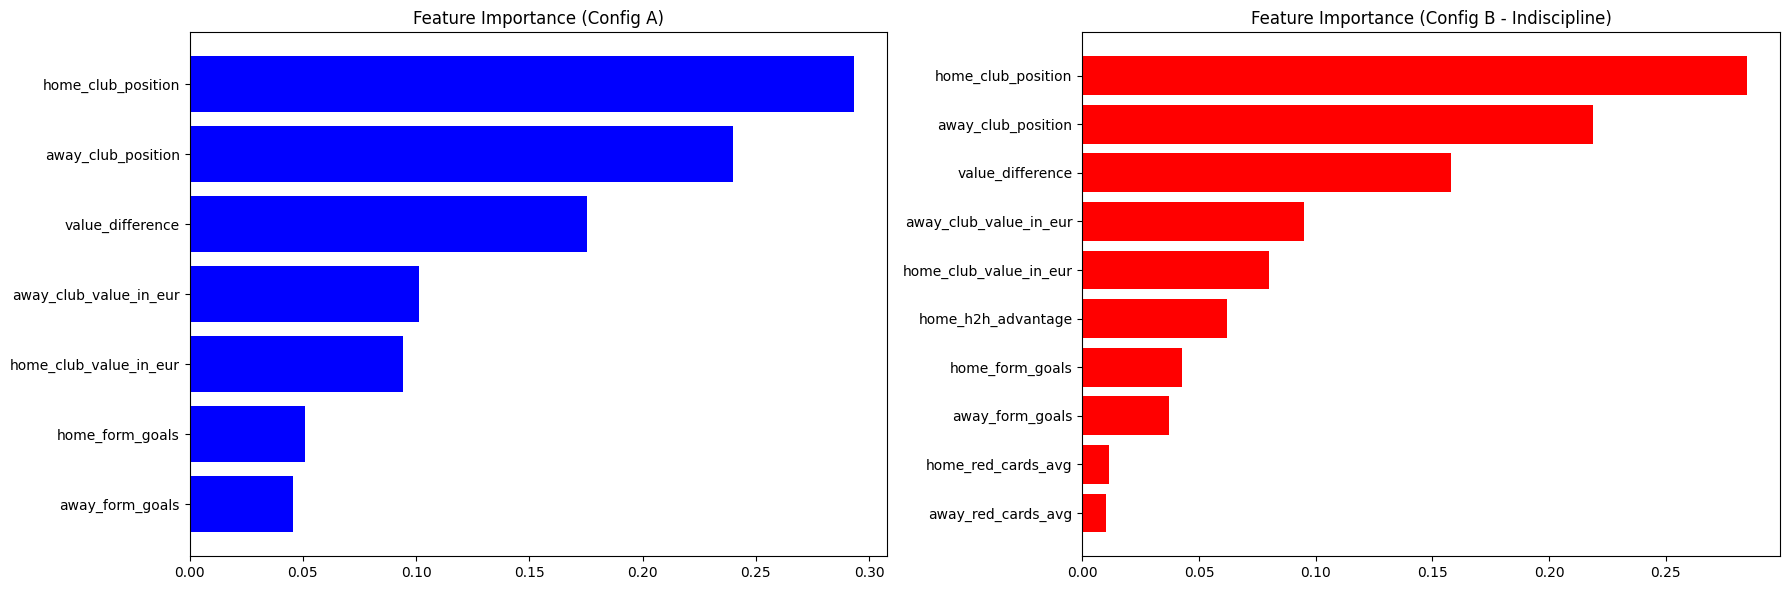

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

importances_A = algo_rf.feature_importances_
features_A_plot = df_model_A.drop(columns=["results"]).columns
indices_A = np.argsort(importances_A)
axes[0].barh(range(len(indices_A)), importances_A[indices_A], color="b", align="center")
axes[0].set_yticks(range(len(indices_A)), [features_A_plot[i] for i in indices_A])
axes[0].set_title("Feature Importance (Config A)")

importances_B = algo_rf_red_cards.feature_importances_
features_B_plot = df_model_B.drop(columns=["results"]).columns
indices_B = np.argsort(importances_B)
axes[1].barh(range(len(indices_B)), importances_B[indices_B], color="r", align="center")
axes[1].set_yticks(range(len(indices_B)), [features_B_plot[i] for i in indices_B])
axes[1].set_title("Feature Importance (Config B - Indiscipline)")
plt.tight_layout()
plt.show()

### Test 5 à 9 : Benchmark de la concurrence

Nous finissons notre panorama en testant des modèles de boosting, de calcul de distance (KNN), de réseaux de neurones et de probabilités Bayesiennes.

In [19]:
print("\n--- TEST 5 : GRADIENT BOOSTING ---")
algo_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
predictor_gb = Predictor(dataframe=df_model_A, model=algo_gb)
predictor_gb.prepare_data()
predictor_gb.train()
predictor_gb.evaluate()

print("\n--- TEST 5 : GRADIENT BOOSTING (Config B - Cartons) ---")
algo_gb_red_cards = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
predictor_gb_red_cards = Predictor(dataframe=df_model_B, model=algo_gb_red_cards)
predictor_gb_red_cards.prepare_data()
predictor_gb_red_cards.train()
predictor_gb_red_cards.evaluate()


--- TEST 5 : GRADIENT BOOSTING ---
Accuracy : 56.76251331203408 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.62      0.60       281
           0       0.29      0.17      0.21       229
           1       0.63      0.75      0.68       429

    accuracy                           0.57       939
   macro avg       0.50      0.51      0.50       939
weighted avg       0.53      0.57      0.54       939


--- TEST 5 : GRADIENT BOOSTING (Config B - Cartons) ---
Accuracy : 56.33652822151225 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.57      0.62      0.59       281
           0       0.27      0.14      0.18       229
           1       0.63      0.75      0.68       429

    accuracy                           0.56       939
   macro avg       0.49      0.50      0.49       939
weighted avg       0.52      0.56      0.53       939



In [20]:
print("\n--- TEST 6 : LINEAR SVC ---")
algo_lsvc = LinearSVC(max_iter=1000, random_state=42)
predictor_lsvc = Predictor(dataframe=df_model_A, model=algo_lsvc)
predictor_lsvc.prepare_data()
predictor_lsvc.train()
predictor_lsvc.evaluate()

print("\n--- TEST 6 : LINEAR SVC (Config B - Cartons) ---")
algo_lsvc_red_cards = LinearSVC(max_iter=1000, random_state=42)
predictor_lsvc_red_cards = Predictor(dataframe=df_model_B, model=algo_lsvc_red_cards)
predictor_lsvc_red_cards.prepare_data()
predictor_lsvc_red_cards.train()
predictor_lsvc_red_cards.evaluate()


--- TEST 6 : LINEAR SVC ---
Accuracy : 59.21192758253461 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.57      0.69      0.62       281
           0       0.00      0.00      0.00       229
           1       0.61      0.84      0.70       429

    accuracy                           0.59       939
   macro avg       0.39      0.51      0.44       939
weighted avg       0.45      0.59      0.51       939


--- TEST 6 : LINEAR SVC (Config B - Cartons) ---
Accuracy : 58.99893503727369 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.56      0.70      0.63       281
           0       0.00      0.00      0.00       229
           1       0.61      0.83      0.70       429

    accuracy                           0.59       939
   macro avg       0.39      0.51      0.44       939
weighted avg       0.45      0.59      0.51       939



/Users/alexandremassieux/Documents/A3/Semestre 2/Ligue1 Matchs Predictions/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexandremassieux/Documents/A3/Semestre 2/Ligue1 Matchs Predictions/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexandremassieux/Documents/A3/Semestre 2/Ligue1 Matchs Predictions/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0

In [21]:
print("\n--- TEST 7 : KNN (K-Nearest Neighbors) ---")
algo_knn = KNeighborsClassifier(n_neighbors=15)
predictor_knn = Predictor(dataframe=df_model_A, model=algo_knn)
predictor_knn.prepare_data()
predictor_knn.train()
predictor_knn.evaluate()

print("\n--- TEST 7 : KNN (K-Nearest Neighbors) (Config B - Cartons) ---")
algo_knn_red_cards = KNeighborsClassifier(n_neighbors=15)
predictor_knn_red_cards = Predictor(dataframe=df_model_B, model=algo_knn_red_cards)
predictor_knn_red_cards.prepare_data()
predictor_knn_red_cards.train()
predictor_knn_red_cards.evaluate()


--- TEST 7 : KNN (K-Nearest Neighbors) ---
Accuracy : 53.78061767838126 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.54      0.58      0.56       281
           0       0.24      0.14      0.18       229
           1       0.61      0.72      0.66       429

    accuracy                           0.54       939
   macro avg       0.47      0.48      0.47       939
weighted avg       0.50      0.54      0.51       939


--- TEST 7 : KNN (K-Nearest Neighbors) (Config B - Cartons) ---
Accuracy : 56.975505857295 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.58      0.62      0.60       281
           0       0.34      0.19      0.24       229
           1       0.62      0.74      0.67       429

    accuracy                           0.57       939
   macro avg       0.51      0.52      0.51       939
weighted avg       0.54      0.57      0.55       939



In [22]:
print("\n--- TEST 8 : RÉSEAU DE NEURONES (MLP) ---")
algo_mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
predictor_mlp = Predictor(dataframe=df_model_A, model=algo_mlp)
predictor_mlp.prepare_data()
predictor_mlp.train()
predictor_mlp.evaluate()

print("\n--- TEST 8 : RÉSEAU DE NEURONES (MLP) (Config B - Cartons) ---")
algo_mlp_red_cards = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
predictor_mlp_red_cards = Predictor(dataframe=df_model_B, model=algo_mlp_red_cards)
predictor_mlp_red_cards.prepare_data()
predictor_mlp_red_cards.train()
predictor_mlp_red_cards.evaluate()


--- TEST 8 : RÉSEAU DE NEURONES (MLP) ---
Accuracy : 53.1416400425985 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.55      0.51      0.53       281
           0       0.30      0.31      0.31       229
           1       0.64      0.66      0.65       429

    accuracy                           0.53       939
   macro avg       0.50      0.49      0.50       939
weighted avg       0.53      0.53      0.53       939


--- TEST 8 : RÉSEAU DE NEURONES (MLP) (Config B - Cartons) ---
Accuracy : 50.47923322683706 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.48      0.50      0.49       281
           0       0.27      0.25      0.26       229
           1       0.64      0.65      0.64       429

    accuracy                           0.50       939
   macro avg       0.46      0.46      0.46       939
weighted avg       0.50      0.50      0.50       939



/Users/alexandremassieux/Documents/A3/Semestre 2/Ligue1 Matchs Predictions/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [23]:
print("\n--- TEST 9 : NAIVE BAYES ---")
algo_nb = GaussianNB()
predictor_nb = Predictor(dataframe=df_model_A, model=algo_nb)
predictor_nb.prepare_data()
predictor_nb.train()
predictor_nb.evaluate()

print("\n--- TEST 9 : NAIVE BAYES (Config B - Cartons) ---")
algo_nb_red_cards = GaussianNB()
predictor_nb_red_cards = Predictor(dataframe=df_model_B, model=algo_nb_red_cards)
predictor_nb_red_cards.prepare_data()
predictor_nb_red_cards.train()
predictor_nb_red_cards.evaluate()


--- TEST 9 : NAIVE BAYES ---
Accuracy : 53.99361022364217 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.61      0.49      0.54       281
           0       0.32      0.45      0.37       229
           1       0.68      0.62      0.65       429

    accuracy                           0.54       939
   macro avg       0.54      0.52      0.52       939
weighted avg       0.57      0.54      0.55       939


--- TEST 9 : NAIVE BAYES (Config B - Cartons) ---
Accuracy : 52.28966986155484 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.57      0.50      0.53       281
           0       0.31      0.41      0.35       229
           1       0.67      0.60      0.63       429

    accuracy                           0.52       939
   macro avg       0.51      0.50      0.50       939
weighted avg       0.55      0.52      0.53       939



### Conclusion de l'Évaluation
Au terme de ces tests, le **Support Vector Machine (Test 2) et la Régression Logistique (Test 1)** restent nos meilleurs modèles. Ils prouvent que la différence de budget et le classement sont des relations linéaires fortes.

On note également que l'ajout des cartons rouges (Config B) aide particulièrement les modèles probabilistes (Naive Bayes), mais a tendance à ajouter un très léger bruit sur les modèles plus complexes.